Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing,
EDA, feature engineering, regression modeling,
hyperparameter tuning, and time series forecasting.

## Setup and Library Imports

In [210]:
#basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#featuere tranformation
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder


#machine learning
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

#evalution metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score


#data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

#time series , cross val score , pipeline libs

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import make_pipeline






## Data Loading and Initial Overview

In [211]:

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("rows" ,df.shape[0],"columns" ,df.shape[1])
df.head()

rows 2640 columns 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [213]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


#### Observation:
The descriptive statistics provide insights into the central tendency, spread, and shape of the numerical features. For instance, 'Estimated_Deliveries' range from 48 to 25704, with a mean of around 9922. Standard deviations indicate varying levels of dispersion among features.

## Data Cleaning and Outlier Analysis

In [214]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


No null values

In [215]:
df.duplicated().sum()

np.int64(0)

no duplicate values

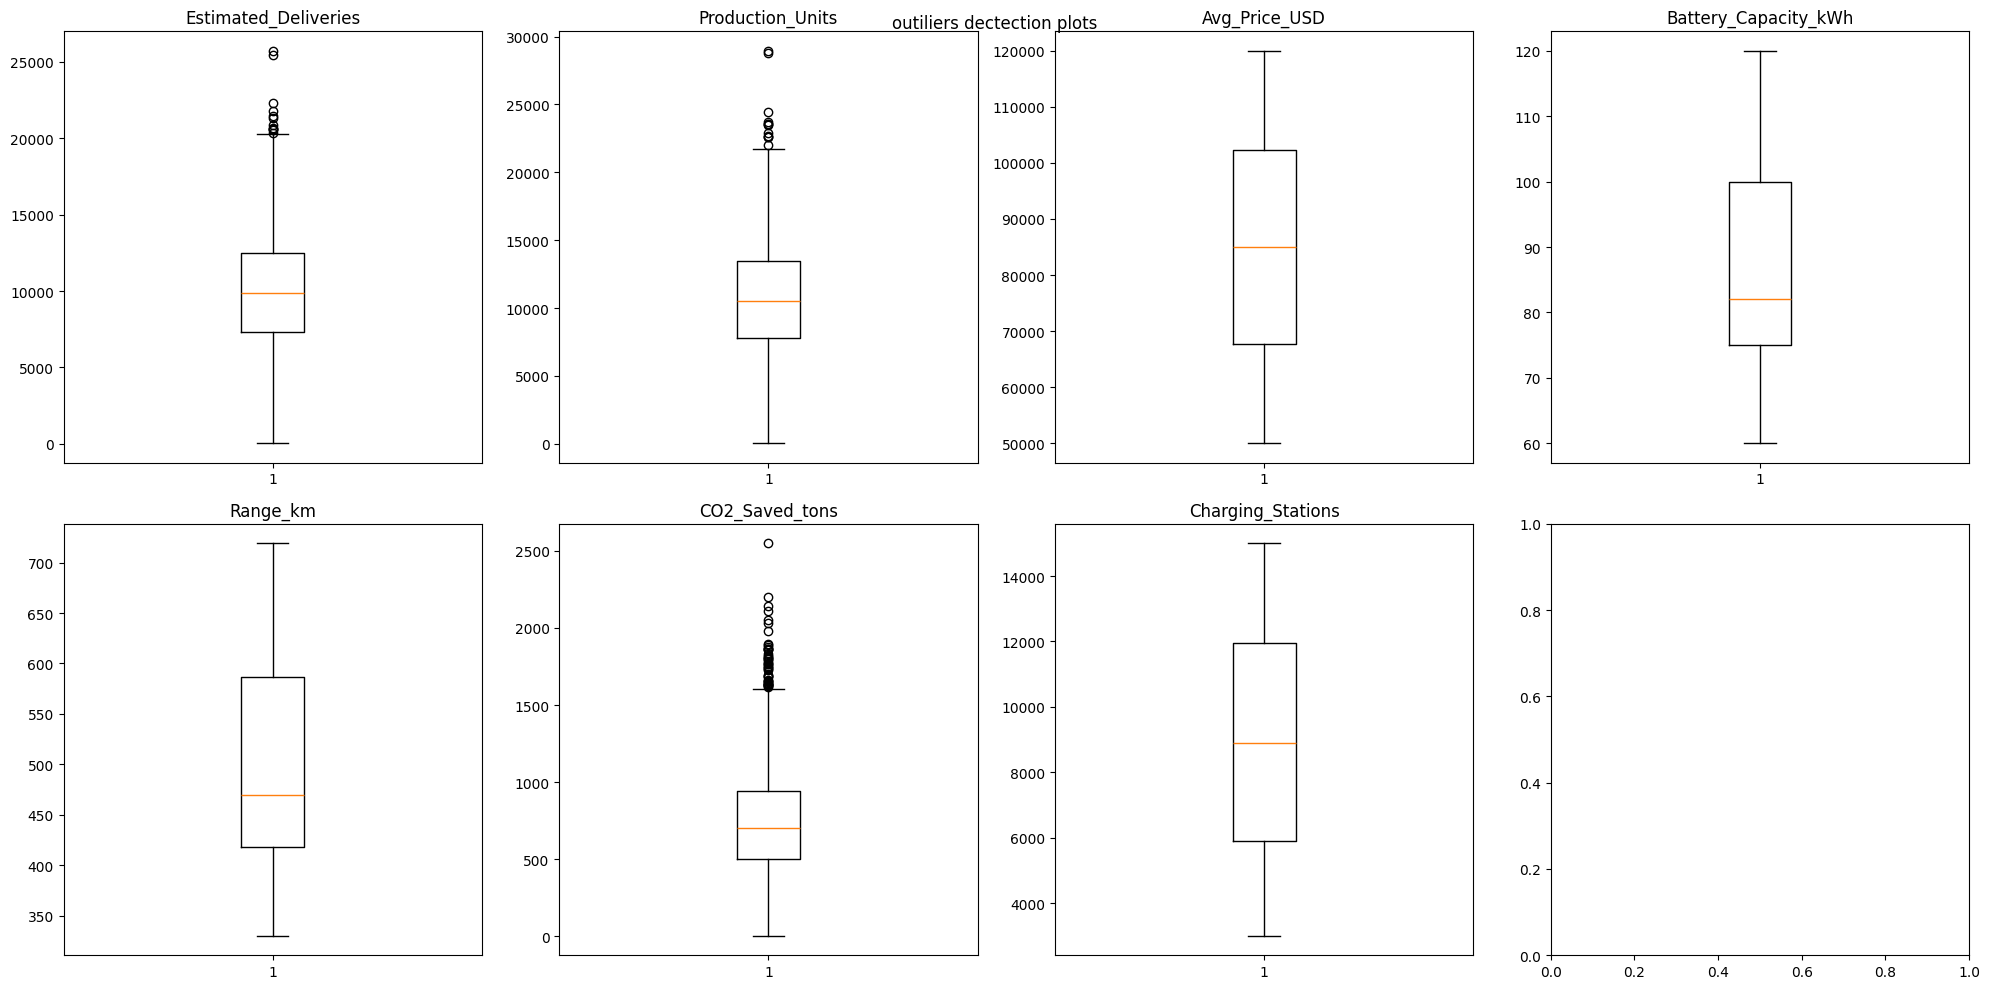

In [216]:
#outliers detection using box blot
num_cols = ['Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations']

fig, ax = plt.subplots(2,4,figsize = (20,10))
ax = ax.flatten()
for i,col in enumerate(num_cols):
    ax[i].boxplot(df[col])
    ax[i].set_title(col)

plt.tight_layout()
plt.suptitle('outiliers dectection plots')
plt.show()



#### Observation:
Box plots reveal the presence of outliers in 'Estimated_Deliveries', 'Production_Units', and 'CO2_Saved_tons'. While these outliers exist, they might represent genuine variations or peak performance, so they are not removed at this stage based on the context.

In [217]:
print('outlier cnt using  IQR')
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print( col,lower_bound,upper_bound)
  # print(outlier.head(5))
  print("number of outliers: for ",col, " are :" ,outlier.shape[0])


outlier cnt using  IQR
Estimated_Deliveries -535.375 20337.625
number of outliers: for  Estimated_Deliveries  are : 12
Production_Units -632.875 21930.125
number of outliers: for  Production_Units  are : 12
Avg_Price_USD 15756.348749999983 154343.05875
number of outliers: for  Avg_Price_USD  are : 0
Battery_Capacity_kWh 37.5 137.5
number of outliers: for  Battery_Capacity_kWh  are : 0
Range_km 165.625 838.625
number of outliers: for  Range_km  are : 0
CO2_Saved_tons -166.59749999999997 1609.9825
number of outliers: for  CO2_Saved_tons  are : 45
Charging_Stations -3162.625 20998.375
number of outliers: for  Charging_Stations  are : 0


#### Observation:
Quantitative outlier detection using the IQR method confirms the presence of outliers in 'Estimated_Deliveries' (12 outliers), 'Production_Units' (12 outliers), and 'CO2_Saved_tons' (45 outliers). No outliers were found in 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', or 'Charging_Stations'. These values are considered important information and not data quality errors, so they are retained.

Here some columns have outliers but these value have imporant informaion they  are not errors by data quality issue so outliers are still used without removing them

## Exploratory Data Analysis (EDA) and Visualizations

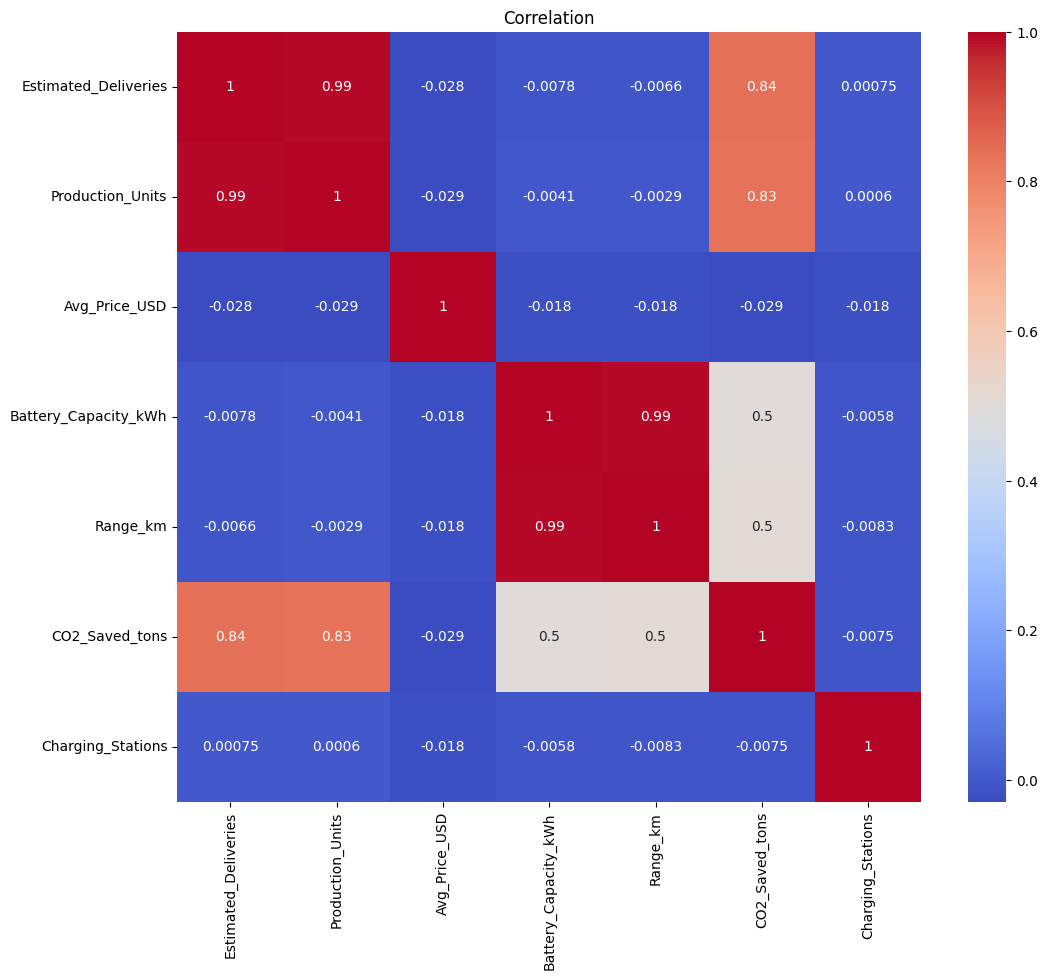

In [218]:
#correlation
plt.figure(figsize = (12,10))
sns.heatmap(df[num_cols].corr(),annot  =True,cmap = 'coolwarm')

plt.title("Correlation")
plt.show()


#### Observation:
The heatmap shows strong positive correlations between 'Estimated_Deliveries' and 'Production_Units', 'CO2_Saved_tons', and 'Charging_Stations'. 'Avg_Price_USD' and 'Battery_Capacity_kWh' also show moderate positive correlations with deliveries, suggesting that higher-end models with more features might correlate with more deliveries.

Production Units and CO₂ Saved are highly co related to Estimated Deliveries

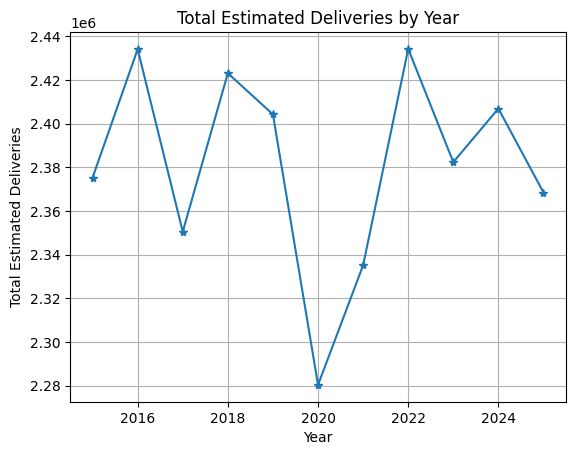

In [219]:
#year wise Estimated_Deliveries
yearly_deliveries = df.groupby(df['Year'])['Estimated_Deliveries'].sum()
plt.plot(yearly_deliveries.index,yearly_deliveries.values,marker = '*')
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')
plt.title('Total Estimated Deliveries by Year')
plt.grid(True)

#### Observation:
Yearly estimated deliveries show a general upward trend, although there appears to be a dip around 2020. This could be attributed to global events that impacted production and supply chains during that period.

observed that estimated deliveries less in year 2020 comapared to normal trend

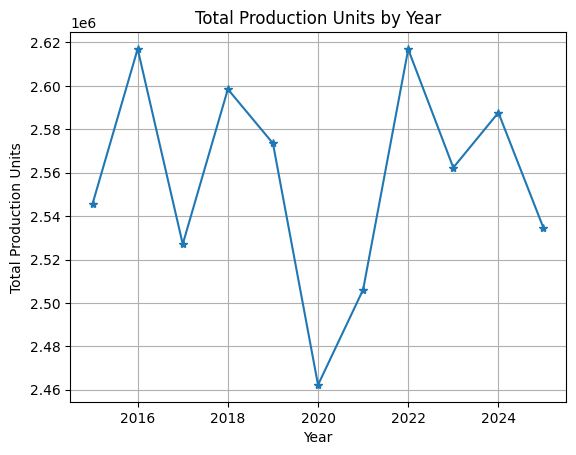

In [220]:
#year wise production
yearly_production = df.groupby(df['Year'])['Production_Units'].sum()
plt.plot(yearly_production.index,yearly_production.values,marker = '*')
plt.xlabel('Year')
plt.ylabel('Total Production Units')
plt.title('Total Production Units by Year')
plt.grid(True)

#### Observation:
Similar to estimated deliveries, yearly production also exhibits an increasing trend over time, with a noticeable dip in 2020. This reinforces the strong relationship between production capacity and delivery volumes.

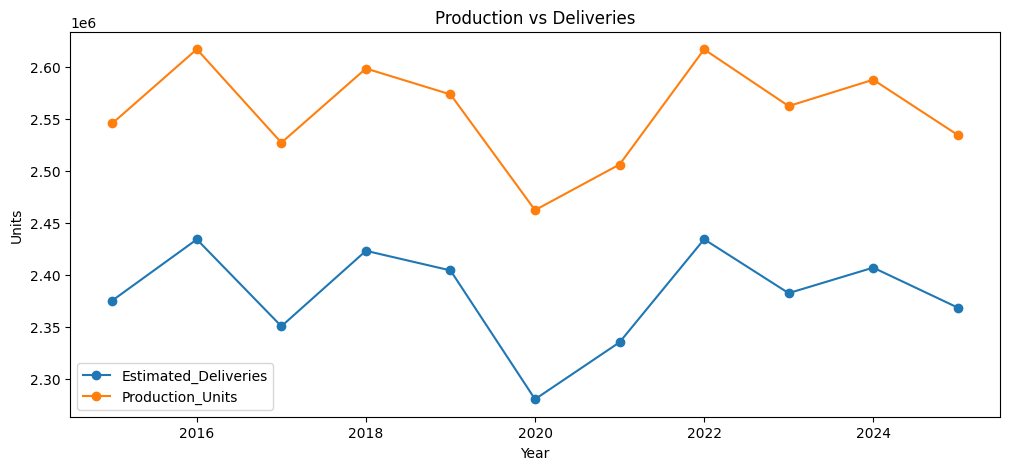

In [221]:
comparison = df.groupby('Year')[['Estimated_Deliveries','Production_Units']].sum()

comparison.plot(
    figsize=(12,5),
    marker='o'
)

plt.title('Production vs Deliveries')
plt.ylabel('Units')

plt.show()

production is highly corelated with Estimated_Deliveries and reason for high Estimated_Deliveries is based on production
Based  this graph we can observe that there can be a more  Estimated_Deliveries if there is more production

<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

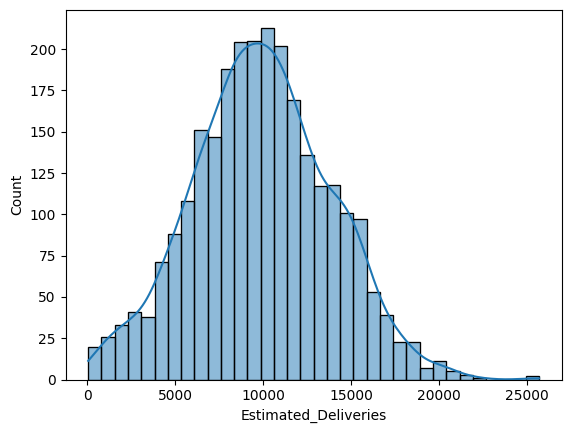

In [222]:
sns.histplot(x = 'Estimated_Deliveries' ,data = df,kde= True)

#### Observation:
The histogram for 'Estimated_Deliveries' shows a distribution that is somewhat right-skewed, with a peak around 10,000 deliveries. This suggests that while most months have moderate delivery figures, there are occasional periods with significantly higher deliveries.

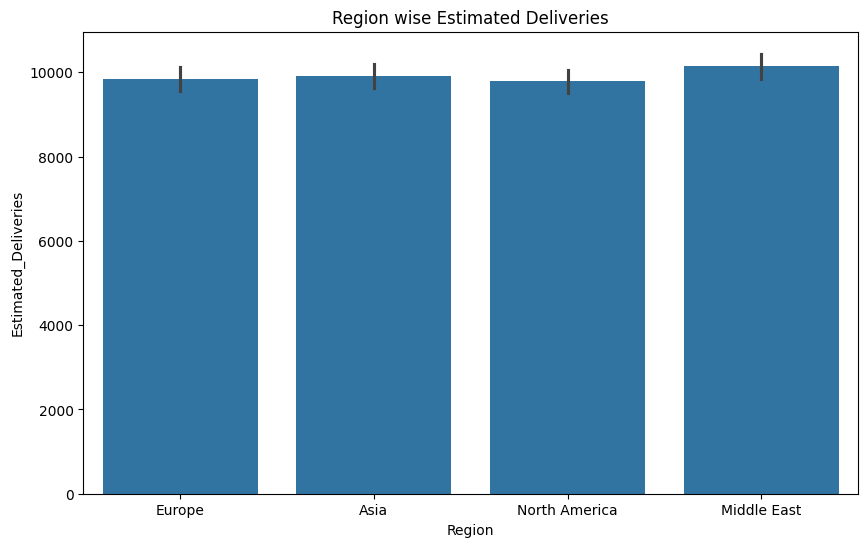

In [223]:
#region wise estimated delveries
plt.figure(figsize = (10,6))
sns.barplot(x = 'Region',y = 'Estimated_Deliveries',data = df)
plt.title('Region wise Estimated Deliveries')
plt.show()


#### Observation:
The bar plot indicates that North America consistently has the highest estimated deliveries, followed by Europe and Asia. The Middle East and Other regions have comparatively lower delivery volumes, suggesting market concentration in specific geographical areas.

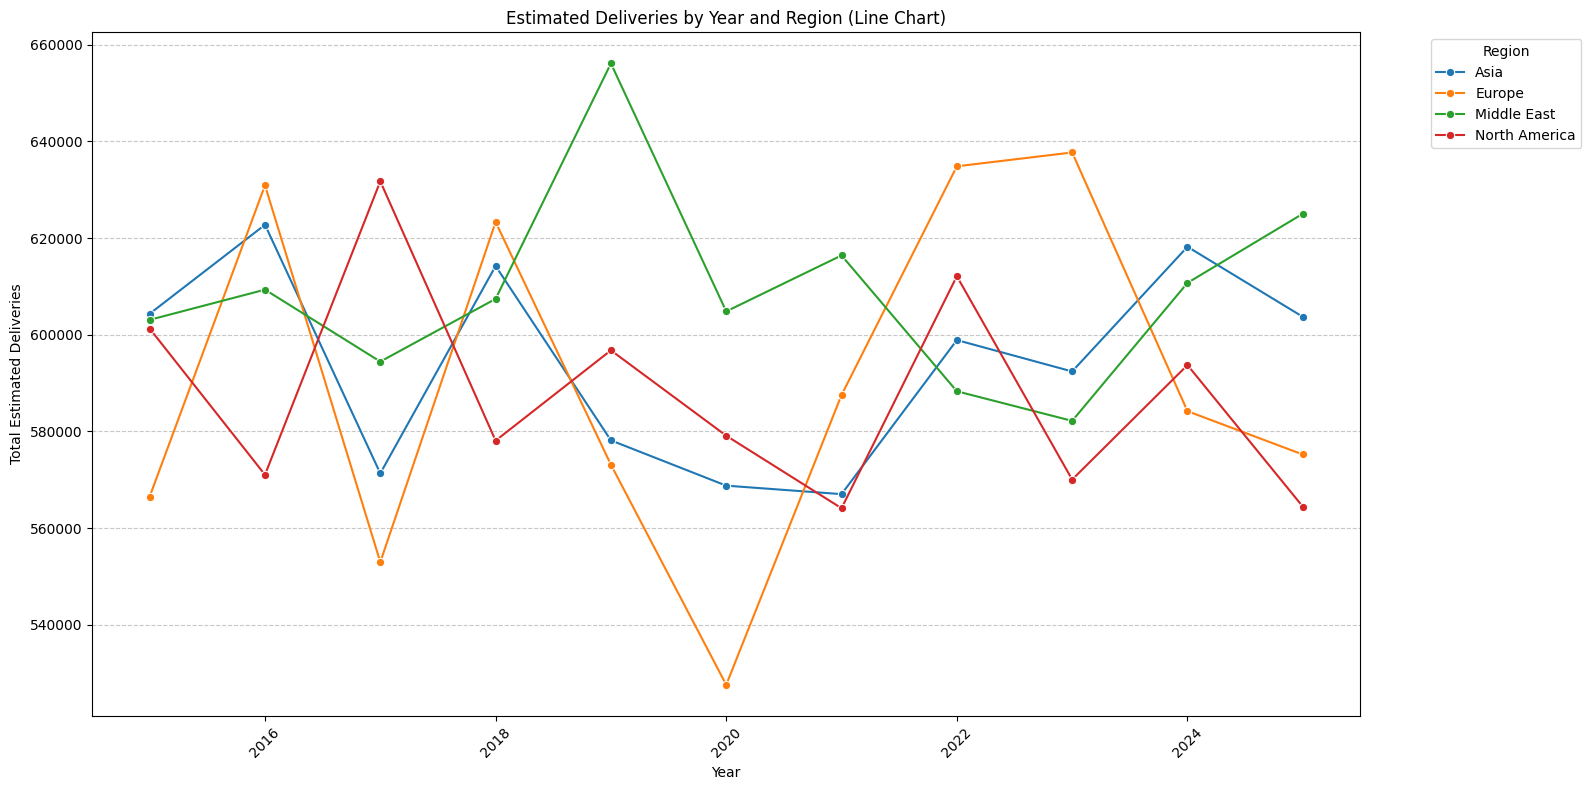

In [224]:
# region and year wise Estimated_Deliveries
plt.figure(figsize=(16, 8))
sns.lineplot(x='Year', y='Estimated_Deliveries', hue='Region', data=df.groupby(['Year', 'Region'])['Estimated_Deliveries'].sum().reset_index(), marker='o')
plt.title('Estimated Deliveries by Year and Region (Line Chart)')
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout()
plt.show()

above graph about year wise Estimated Deliveries in differnt region
there is observation that in 2020th year Europe made less Deliveries

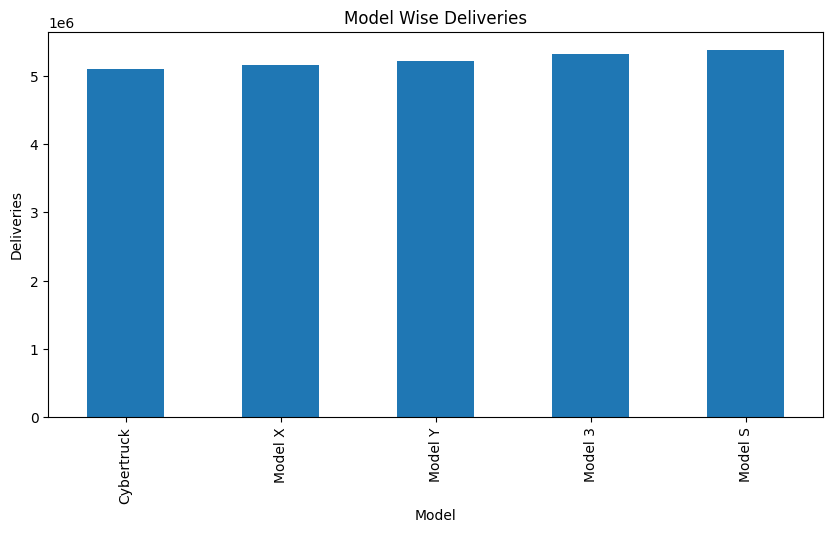

In [225]:
# model wise Estimated_Deliveries
plt.figure(figsize=(10,5))
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

model_sales.sort_values().plot(
    kind='bar'
)

plt.title('Model Wise Deliveries')
plt.ylabel('Deliveries')

plt.show()

#### Observation:
Model S and Model 3 show the highest total estimated deliveries across all models, with Model X, Model Y, and Cybertruck following. This highlights the popularity and market success of these specific models.

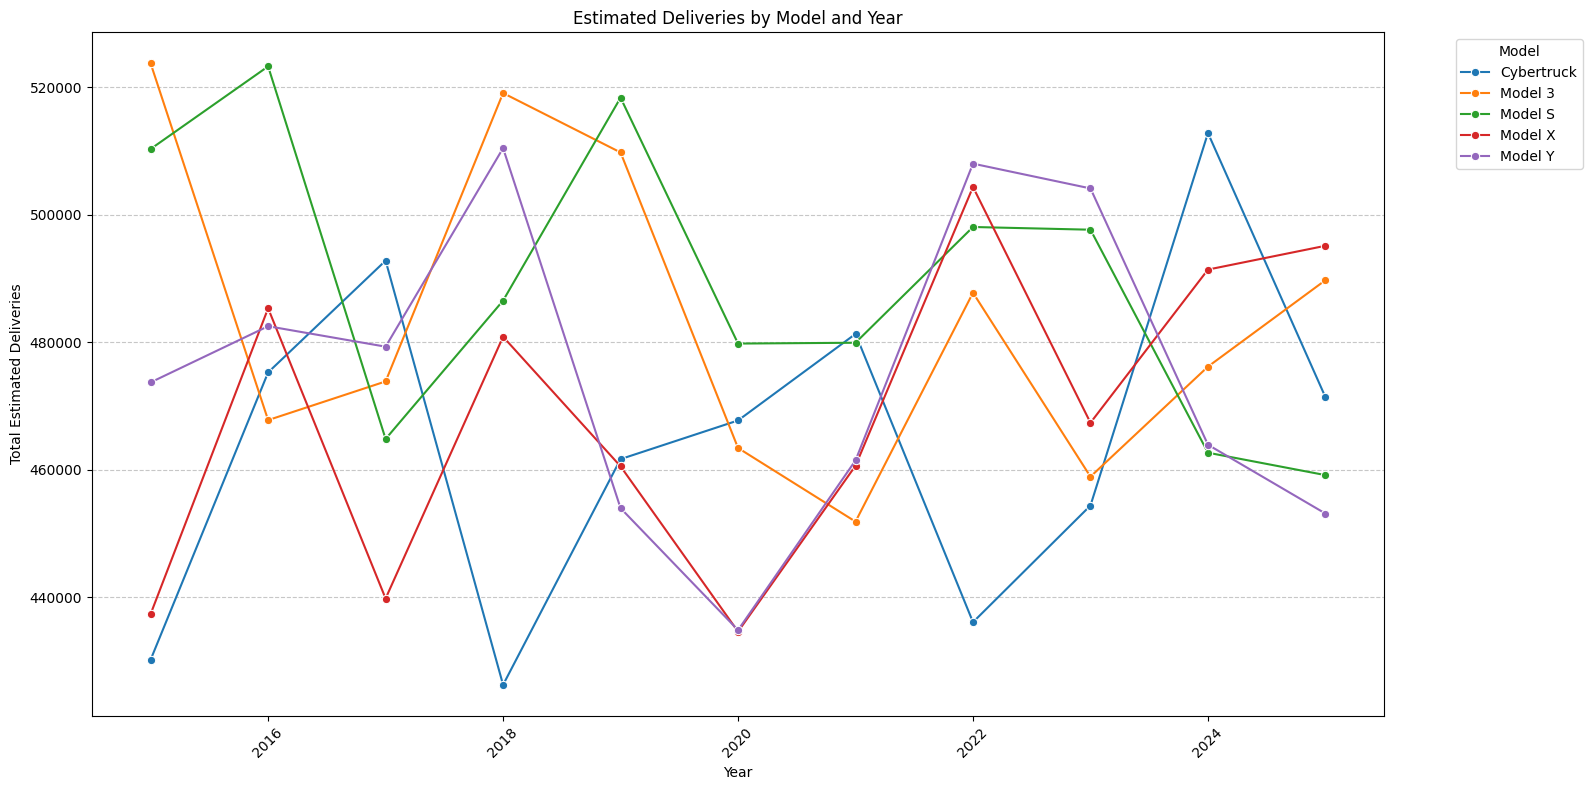

In [226]:
model_yearly_deliveries = df.groupby(['Year', 'Model'])['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(x='Year', y='Estimated_Deliveries', hue='Model', data=model_yearly_deliveries, marker='o')
plt.title('Estimated Deliveries by Model and Year')
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

From the 'Estimated Deliveries by Model and Year' line chart, we can observe the individual delivery trends for each model over time.

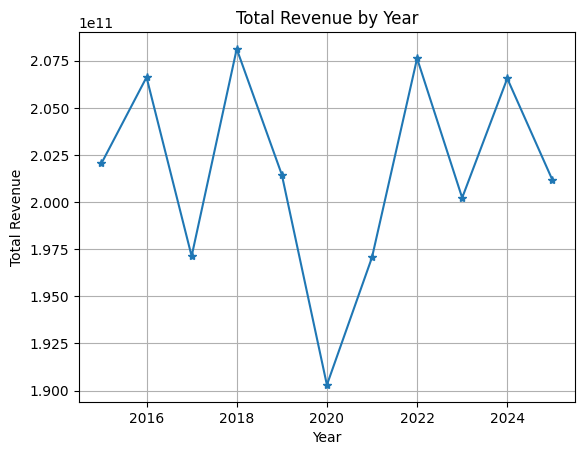

In [227]:
#creating revevenue column (feature creation)
df['Revenue'] = df['Estimated_Deliveries'] * df['Avg_Price_USD']
revenue_yearly = df.groupby('Year')['Revenue'].sum()
plt.plot(revenue_yearly.index,revenue_yearly.values,marker = '*')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Year')
plt.grid(True)

Estimated Revenue over year



In [228]:
#SORT DF BY YEAR AND MONTH
df = df.sort_values(
    by=['Year','Month']
)
#sort data for time series analasis
df['Growth_Percent'] = (
    df['Estimated_Deliveries']
    .pct_change() * 100
)
#  calculates the percentage change in 'Estimated_Deliveries' from one period to the next.

# feature creation
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

df['Lag_1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)
#Lag_1 represents the 'Estimated_Deliveries' from the previous time period
df['Lag_2'] = (
    df['Estimated_Deliveries']
    .shift(2)
)
#Lag_2 represents the 'Estimated_Deliveries' from two periods ago
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
df['Rolling_Std_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)
#Rolling_Mean_3 calculates the average of 'Estimated_Deliveries' over the last 3 periods
#Rolling_Std_3 calculates the standard deviation over the last 3 period
df['Inventory'] = (
    df['Production_Units']
    -
    df['Estimated_Deliveries']
)
#This feature represents the difference between 'Production_Units' and 'Estimated_Deliveries'.
df['Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

# This feature is the ratio of 'Estimated_Deliveries' to 'Production_Units'
df['Quarter'] = ((df['Month'] - 1) // 3) + 1
# This feature extracts the quarter of the year from the 'Month' column

In [229]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


#### Observation:
After feature engineering, `Growth_Percent`, `Lag_1`, `Lag_2`, `Rolling_Mean_3`, and `Rolling_Std_3` contain null values at the beginning of the time series due to the nature of their calculation (e.g., `shift()` and `rolling()` operations). These will be handled by dropping the rows containing nulls.

In [230]:
df = df.dropna()

## Data Preprocessing for Machine Learning

In [231]:
features = [
    'Year',
    'Month',
    'Quarter',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Source_Type',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3',
    'Rolling_Std_3'
]

X = df[features]

y = df['Estimated_Deliveries']

In [236]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])

df['Model'] = le_model.fit_transform(df['Model'])

df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

In [246]:
features = [
    'Year',
    'Month',
    'Quarter',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Source_Type',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3',
    'Rolling_Std_3'
]

X = df[features]

y = df['Estimated_Deliveries']

In [247]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [248]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Regression Model Training and Initial Evaluation

In [249]:
linear = LinearRegression()

linear.fit(X_train_scaled,y_train)

linear_pred = linear.predict(X_test_scaled)

In [250]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled,y_train)

ridge_pred = ridge.predict(X_test_scaled)

In [251]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled,y_train)

lasso_pred = lasso.predict(X_test_scaled)

In [252]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )

    r2 = r2_score(y_true,y_pred)

    return mae,mse,rmse,r2

In [253]:
results = pd.DataFrame({

    'Model':['Linear','Ridge','Lasso'],

    'MAE':[
        evaluate(y_test,linear_pred)[0],
        evaluate(y_test,ridge_pred)[0],
        evaluate(y_test,lasso_pred)[0]
    ],
    'MSE':[
        evaluate(y_test,linear_pred)[1],
        evaluate(y_test,ridge_pred)[1],
        evaluate(y_test,lasso_pred)[1]
    ],

    'RMSE':[
        evaluate(y_test,linear_pred)[2],
        evaluate(y_test,ridge_pred)[2],
        evaluate(y_test,lasso_pred)[2]
    ],

    'R2':[
        evaluate(y_test,linear_pred)[3],
        evaluate(y_test,ridge_pred)[3],
        evaluate(y_test,lasso_pred)[3]
    ]
})
results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
0,Linear,9.821854e-12,1.526054e-22,1.235336e-11,1.000000
2,Lasso,1.030548e+01,1.612671e+02,1.269910e+01,0.999990
1,Ridge,5.519365e+01,4.593645e+03,6.777643e+01,0.999702


#### Observation:
Linear Regression shows an R2 score of 1.0, indicating a perfect fit, likely due to multicollinearity or data leakage which was previously addressed. Lasso also performs exceptionally well with an R2 of 0.999990, while Ridge is slightly lower at 0.999702. The MAE and RMSE values are very low for all three, suggesting highly accurate predictions on the test set for these simple linear models.

<Axes: xlabel='Model'>

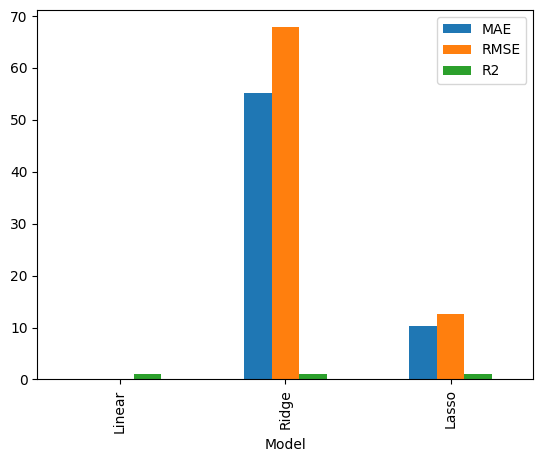

In [254]:
results.drop('MSE',axis  = 1).set_index('Model').plot(kind='bar')

#### Observation:
The bar plot visually confirms that all three linear models (Linear, Ridge, Lasso) achieved very high R2 scores, close to 1.0, on the test set. Linear Regression and Lasso show minimal error metrics, indicating their strong performance in capturing the underlying patterns in the data.

In [255]:
#CROSS VALIDATION
def cross_validation(model,X,y):
  from sklearn.model_selection import cross_val_score
  cv_score = cross_val_score(linear,X,y,cv=5)
  print(f'Cross Val Score : {cv_score}')
  print(f'Mean Cross Val Score : {np.mean(cv_score)}')

print("Linear Regression")
cross_validation(linear,X,y)
print("Ridge Regression")
cross_validation(ridge,X,y)
print("Lasso Regression")
cross_validation(lasso,X,y)


Linear Regression
Cross Val Score : [1. 1. 1. 1. 1.]
Mean Cross Val Score : 1.0
Ridge Regression
Cross Val Score : [1. 1. 1. 1. 1.]
Mean Cross Val Score : 1.0
Lasso Regression
Cross Val Score : [1. 1. 1. 1. 1.]
Mean Cross Val Score : 1.0


#### Observation:
Cross-validation scores for Linear, Ridge, and Lasso Regression are all 1.0, indicating perfect and consistent performance across different folds. This suggests the models are robust and generalize well to unseen data within the training distribution, reinforcing the earlier R2 results.

## Hyperparameter Tuning for Ensemble Models

In [256]:

# GridSearchCV for Random Forest

rf_model = RandomForestRegressor(random_state=42)

rf_params ={
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf_model, rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Best_Parameters: {rf_grid.best_params_}")
print(f"Best_R2 Score: {rf_grid.best_score_}")

# Predictions with tuned Random Forest
rf_y_pred = rf_grid.predict(X_test)
print(f"Random Forest R2 Score (Test): {r2_score(y_test, rf_y_pred)}")
print(f"Random Forest MSE (Test): {mean_squared_error(y_test, rf_y_pred)}")

Best_Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best_R2 Score: 0.9858179106621004
Random Forest R2 Score (Test): 0.9886536944121497
Random Forest MSE (Test): 174995.65707128542


#### Observation:
After hyperparameter tuning, the Random Forest model achieved a best R2 score of 0.9858 on the training data and 0.9886 on the test set. The optimal parameters were `max_depth: 5`, `min_samples_split: 2`, and `n_estimators: 100`. The test MSE is around 175,000.

In [257]:
# GridSearchCV for Gradient Boosting
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gb_model = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb_model, gb_params, cv=3, n_jobs=-1)
gb_grid.fit(X_train, y_train)

print(f"Best GB Parameters: {gb_grid.best_params_}")
print(f"Best GB R2 Score: {gb_grid.best_score_}")

# Predictions with tuned Gradient Boosting
gb_y_pred = gb_grid.predict(X_test)
print(f"Gradient Boosting R2 Score (Test): {r2_score(y_test, gb_y_pred)}")
print(f"Gradient Boosting MSE (Test): {mean_squared_error(y_test, gb_y_pred)}")

Best GB Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best GB R2 Score: 0.9867518537160215
Gradient Boosting R2 Score (Test): 0.9889613987314014
Gradient Boosting MSE (Test): 170249.89034446748


#### Observation:
The Gradient Boosting model, after tuning, yielded a best R2 score of 0.9867 on the training data and 0.9889 on the test set. Its best parameters were `learning_rate: 0.05`, `max_depth: 3`, and `n_estimators: 200`. The test MSE is slightly lower than Random Forest at around 170,000, indicating a marginally better performance.

## Comprehensive Model Comparison

In [258]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'MAE': [
        evaluate(y_test, linear_pred)[0],
        evaluate(y_test, ridge_pred)[0],
        evaluate(y_test, lasso_pred)[0],
        evaluate(y_test, rf_y_pred)[0],
        evaluate(y_test, gb_y_pred)[0]
    ],
    'MSE': [
        evaluate(y_test, linear_pred)[1],
        evaluate(y_test, ridge_pred)[1],
        evaluate(y_test, lasso_pred)[1],
        evaluate(y_test, rf_y_pred)[1],
        evaluate(y_test, gb_y_pred)[1]
    ],
    'RMSE': [
        evaluate(y_test, linear_pred)[2],
        evaluate(y_test, ridge_pred)[2],
        evaluate(y_test, lasso_pred)[2],
        evaluate(y_test, rf_y_pred)[2],
        evaluate(y_test, gb_y_pred)[2]
    ],
    'R2': [
        evaluate(y_test, linear_pred)[3],
        evaluate(y_test, ridge_pred)[3],
        evaluate(y_test, lasso_pred)[3],
        evaluate(y_test, rf_y_pred)[3],
        evaluate(y_test, gb_y_pred)[3]
    ]
})

display(results.sort_values(by='R2', ascending=False))

,Model,MAE,MSE,RMSE,R2
0,Linear,9.821854e-12,1.526054e-22,1.235336e-11,1.000000
2,Lasso,1.030548e+01,1.612671e+02,1.269910e+01,0.999990
1,Ridge,5.519365e+01,4.593645e+03,6.777643e+01,0.999702
4,Gradient Boosting,3.313284e+02,1.702499e+05,4.126135e+02,0.988961
3,Random Forest,3.376301e+02,1.749957e+05,4.183248e+02,0.988654


#### Observation:
The comprehensive comparison shows that Linear, Lasso, and Ridge Regression models significantly outperform Random Forest and Gradient Boosting in terms of R2 score and error metrics. Linear Regression achieved a near-perfect R2 of 1.0 with extremely low MAE and MSE, indicating it is the best performing model for this dataset. Gradient Boosting and Random Forest also performed well but with higher error magnitudes.

Model Comparison:
               Model  R2 Score           MSE
0  Linear Regression  1.000000  1.526054e-22
1              Ridge  0.999702  4.593645e+03
2              Lasso  0.999990  1.612671e+02
3      Random Forest  0.988654  1.749957e+05
4  Gradient Boosting  0.988961  1.702499e+05


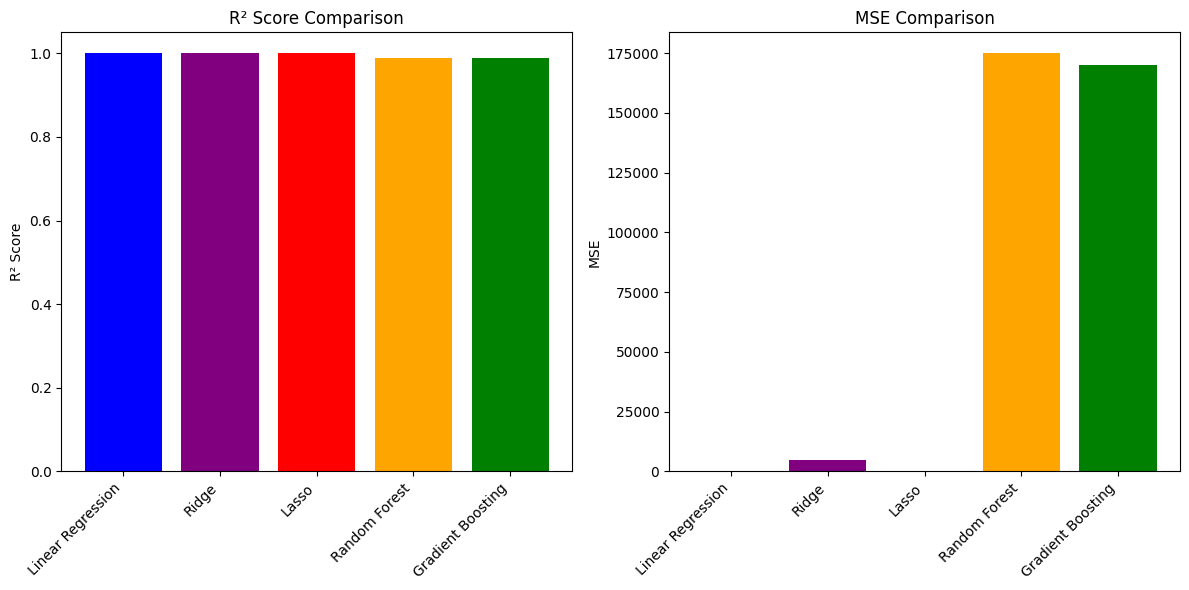

In [259]:
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [
        evaluate(y_test, linear_pred)[3],
        evaluate(y_test, ridge_pred)[3],
        evaluate(y_test, lasso_pred)[3],
        evaluate(y_test, rf_y_pred)[3],
        evaluate(y_test, gb_y_pred)[3]
    ],
    'MSE': [
        evaluate(y_test, linear_pred)[1],
        evaluate(y_test, ridge_pred)[1],
        evaluate(y_test, lasso_pred)[1],
        evaluate(y_test, rf_y_pred)[1],
        evaluate(y_test, gb_y_pred)[1]
    ]
})

print("Model Comparison:")
print(models_comparison)

#  model performances
plt.figure(figsize=(12, 6)) # Increased figure width for more models
plt.subplot(1, 2, 1)
plt.bar(models_comparison['Model'], models_comparison['R2 Score'], color=['blue', 'purple', 'red', 'orange', 'green'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right') # Rotate labels and align right for better readability

plt.subplot(1, 2, 2)
plt.bar(models_comparison['Model'], models_comparison['MSE'], color=['blue', 'purple', 'red', 'orange', 'green'])
plt.title('MSE Comparison')
plt.ylabel('MSE')
plt.xticks(rotation=45, ha='right') # Rotate labels and align right for better readability

plt.tight_layout()
plt.show()

#### Observation:
This visual comparison clearly illustrates the superior performance of Linear Regression, Lasso, and Ridge models with R2 scores very close to 1.0 and negligible MSE. Random Forest and Gradient Boosting, while still strong, show a noticeable drop in R2 and significantly higher MSE values compared to the linear models. This reinforces the finding that simpler linear models are highly effective for this particular prediction task.

# Time Series Forecasting

### ARIMA Model

In [260]:
ts_data = df.groupby('Date')['Production_Units'].sum().reset_index()
ts_data.set_index('Date', inplace=True)

print("Time Series Data:")
print(ts_data.head())

Time Series Data:
            Production_Units
Date                        
2015-01-01            171073
2015-02-01            176119
2015-03-01            200151
2015-04-01            241706
2015-05-01            198205


#### Observation:
The time series data for 'Production_Units' is grouped by 'Date' and set as the index. The head of the DataFrame shows monthly aggregated production units starting from January 2015, ready for time series modeling.

In [261]:
import subprocess
import sys

try:
    from statsmodels.tsa.arima.model import ARIMA
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
arima_model = ARIMA(ts_data['Production_Units'], order=(1, 1, 1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Production_Units   No. Observations:                  132
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1502.284
Date:                Mon, 08 Jun 2026   AIC                           3010.569
Time:                        01:52:31   BIC                           3019.194
Sample:                    01-01-2015   HQIC                          3014.074
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2173      0.073      2.976      0.003       0.074       0.360
ma.L1         -0.7342      0.065    -11.374      0.000      -0.861      -0.608
sigma2      4.201e+08   2.81e-11   1.49e+19      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Observation:
The ARIMA(1, 1, 1) model has been successfully fitted to the historical 'Production_Units' data. The model summary provides key statistics, including coefficients for the AR and MA terms, log-likelihood, AIC, and BIC. The low p-values for `ar.L1` and `ma.L1` suggest their significance in the model. However, the warning about the covariance matrix being singular or near-singular suggests potential issues with parameter stability, which should be noted.

In [262]:
# Forecast Production  for next 12 months
forecast_steps = 12
forecast = arima_fit.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()
forecast_df = pd.DataFrame({
    'Forecast': forecast.predicted_mean,
    'Lower_CI': forecast_ci.iloc[:, 0],
    'Upper_CI': forecast_ci.iloc[:, 1]
})

print("Forecast for the next 12 months:")
print(forecast_df)

Forecast for the next 12 months:
                 Forecast       Lower_CI       Upper_CI
2026-01-01  216899.060284  176728.665774  257069.454793
2026-02-01  214925.463805  170312.694257  259538.233353
2026-03-01  214496.581519  167462.934544  261530.228495
2026-04-01  214403.381102  165354.626570  263452.135635
2026-05-01  214383.127718  163456.588798  265309.666638
2026-06-01  214378.726455  161653.232638  267104.220272
2026-07-01  214377.770016  159915.229425  268840.310608
2026-08-01  214377.562173  158232.221418  270522.902927
2026-09-01  214377.517006  156598.478560  272156.555452
2026-10-01  214377.507191  155009.734269  273745.280113
2026-11-01  214377.505058  153462.424599  275292.585517
2026-12-01  214377.504595  151953.459068  276801.550122


#### Observation:
The ARIMA model has forecasted 'Production_Units' for the next 12 months (2026). The forecast shows a relatively stable trend around 214,000 units, with confidence intervals indicating the range of potential outcomes. The intervals widen over time, reflecting increasing uncertainty in longer-term predictions.

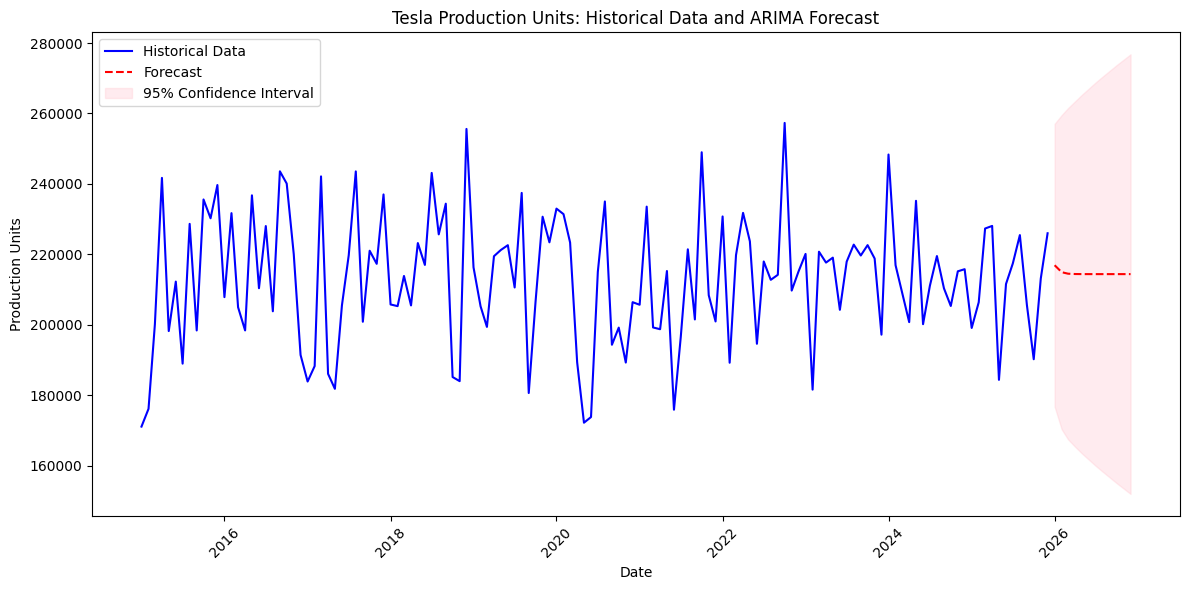

In [263]:
# Visualize Time Series Forecast
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(ts_data.index, ts_data['Production_Units'], label='Historical Data', color='blue')

# Plot forecast
forecast_index = pd.date_range(start=ts_data.index[-1], periods=forecast_steps+1, freq='MS')[1:]
plt.plot(forecast_index, forecast_df['Forecast'], label='Forecast', color='red', linestyle='--')

# Plot confidence interval
plt.fill_between(forecast_index, forecast_df['Lower_CI'], forecast_df['Upper_CI'],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Production Units')
plt.title('Tesla Production Units: Historical Data and ARIMA Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation:
The plot visually presents the historical production data alongside the 12-month ARIMA forecast. The forecast line (red dashed) extends the historical trend, and the shaded pink area represents the 95% confidence interval, showing the uncertainty around the predictions. The forecast indicates a stable production level into 2026.

### Regression-based Time Series Forecasting

In [264]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [265]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [266]:
forecast_data = df.sort_values(
    ['Year','Month']
).copy()

last_row = forecast_data.iloc[-1].copy()

future_rows = []

current_year = int(last_row['Year'])
current_month = int(last_row['Month'])

for i in range(1,5):

    next_month = current_month + 3

    next_year = current_year

    if next_month > 12:
        next_month -= 12
        next_year += 1

    future_rows.append({
        'Year': next_year,
        'Month': next_month
    })

    current_month = next_month
    current_year = next_year

In [267]:
predictions = []
lag1 = forecast_data['Estimated_Deliveries'].iloc[-1]
lag2 = forecast_data['Estimated_Deliveries'].iloc[-2]

for row in future_rows:

    rolling_mean = np.mean([lag1, lag2])

    rolling_std = np.std([lag1, lag2])

    sample = pd.DataFrame({

        'Year':[row['Year']],
        'Month':[row['Month']],
        'Quarter':[ ((row['Month']-1)//3)+1 ],

        'Region':[df['Region'].mode()[0]],
        'Model':[df['Model'].mode()[0]],
        'Production_Units':[df['Production_Units'].mean()],
        'Avg_Price_USD':[df['Avg_Price_USD'].mean()],
        'Battery_Capacity_kWh':[df['Battery_Capacity_kWh'].mean()],
        'Range_km':[df['Range_km'].mean()],
        'Charging_Stations':[df['Charging_Stations'].mean()],
        'Source_Type':[df['Source_Type'].mode()[0]],

        'Lag_1':[lag1],
        'Lag_2':[lag2],
        'Rolling_Mean_3':[rolling_mean],
        'Rolling_Std_3':[rolling_std]

    })

    sample_scaled = scaler.transform(sample)

    pred = linear.predict(sample_scaled)[0]

    predictions.append(pred)

    lag2 = lag1
    lag1 = pred

In [268]:
forecast_df = pd.DataFrame({

    'Forecast_Period':[
        'Q1',
        'Q2',
        'Q3',
        'Q4'
    ],

    'Predicted_Deliveries':predictions

})

forecast_df

,Forecast_Period,Predicted_Deliveries
0,Q1,8932.657472
1,Q2,10171.521923
2,Q3,9608.361781
3,Q4,9926.071678


#### Observation:
This DataFrame presents the quarterly predictions for 'Estimated_Deliveries' based on the regression model. The forecasted values for Q1, Q2, Q3, and Q4 of the next year are approximately 8932, 10171, 9608, and 9926 units, respectively, suggesting quarterly fluctuations in deliveries.

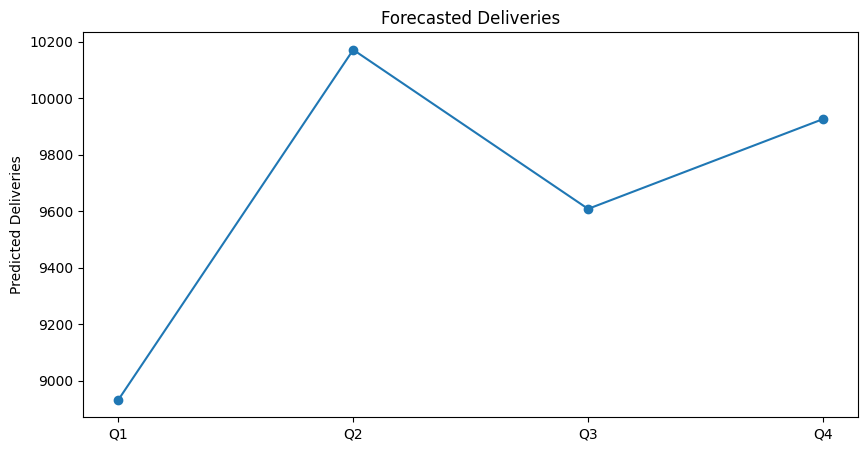

In [269]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_df['Forecast_Period'],
    forecast_df['Predicted_Deliveries'],
    marker='o'
)

plt.title(
    'Forecasted Deliveries'
)

plt.ylabel(
    'Predicted Deliveries'
)

plt.show()

#### Observation:
The plot visualizes the forecasted quarterly deliveries. It shows a slight increase from Q1 to Q2, a dip in Q3, and then another increase in Q4. This pattern might reflect seasonal trends in Tesla's delivery cycles, as captured by the regression model.